# Comparación: Regresión Logística vs SVM (Lineal y RBF)
Dataset: `diabetes_prediction_dataset.csv`  
Objetivo: comparar modelos de **clasificación** para predecir `diabetes` (0/1) siguiendo los siguientes bloques:
1) Preparación
2) Regresión logística
3) SVM lineal
4) SVM con kernel RBF



> Nota: los cálculos pueden ralentizarse, el Dataset está en el límite de empezar a ser difícil de manejar

## 0. Importaciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_moons, make_circles
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz, DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, r2_score, mean_squared_error, roc_curve, roc_auc_score, ConfusionMatrixDisplay, confusion_matrix

## 1) Bloque 1 — Preparación: carga y exploración
Objetivo del bloque: dejar el dataset listo para entrenar modelos.

- Detectamos columnas numéricas y categóricas.
- Hacemos `train_test_split` con `stratify=y`.
- **Escalamos** numéricas (imprescindible para SVM).
- Codificamos categóricas con One-Hot.


In [2]:
df_diabetes = pd.read_csv("diabetes_prediction_dataset.csv")
df_diabetes.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
df_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [4]:
df_diabetes = pd.get_dummies(df_diabetes, dtype=int)

In [5]:
df_diabetes.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,1,0,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,1,0,0,1,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,0,0,1,0,0,0,0,0,1,0
3,36.0,0,0,23.45,5.0,155,0,1,0,0,0,1,0,0,0,0
4,76.0,1,1,20.14,4.8,155,0,0,1,0,0,1,0,0,0,0


In [6]:
X = df_diabetes.drop(["diabetes"],axis=1)
y = df_diabetes["diabetes"]

print(X.shape)
print(y.shape)

(100000, 15)
(100000,)


In [7]:
escalador = StandardScaler()
X = escalador.fit_transform(X)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify=y)

### Funciones auxiliares de evaluación
Calculamos métricas estándar y pintamos:
- No olvidar Matriz de confusión

In [9]:
df_diabetes.corr(numeric_only=True)["diabetes"].abs().sort_values(ascending=False)[1:]

blood_glucose_level            0.419558
HbA1c_level                    0.400660
age                            0.258008
bmi                            0.214357
hypertension                   0.197823
heart_disease                  0.171727
smoking_history_No Info        0.118939
smoking_history_former         0.097917
gender_Male                    0.037666
gender_Female                  0.037553
smoking_history_never          0.027267
smoking_history_ever           0.024080
smoking_history_not current    0.020734
smoking_history_current        0.019606
gender_Other                   0.004090
Name: diabetes, dtype: float64

## 2) Bloque 2 — Regresión Logística
Entrenamos una regresión logística y evaluamos.



In [10]:
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

LogisticRegression()

AUC del modelo: 0.9625


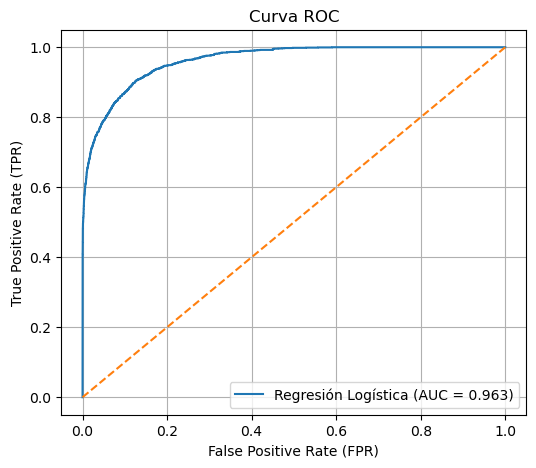

In [11]:
# 2️. Obtenemos probabilidades de la clase positiva
y_prob = modelo.predict_proba(X_test)[:, 1]

# 3️. Calculamos puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# 4️. Calculamos AUC
auc = roc_auc_score(y_test, y_prob)

print(f"AUC del modelo: {auc:.4f}")

# 5️. Representación gráfica
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Regresión Logística (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")  # Línea diagonal (modelo aleatorio)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Curva ROC")
plt.legend()
plt.grid()
plt.show()

In [12]:
y_pred = modelo.predict(X_test)

In [13]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

MSE: 0.0395
RMSE: 0.1987
MAE: 0.0395
R2: 0.4921


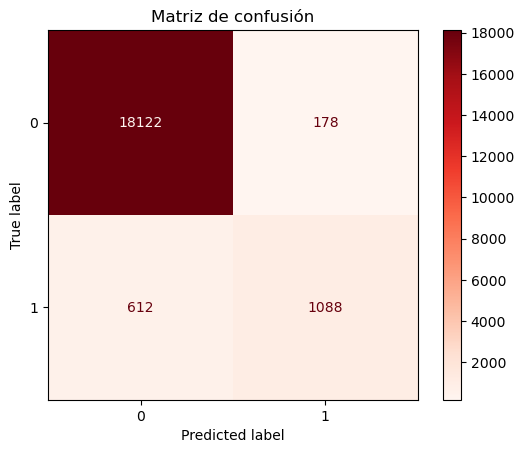

Accuracy:  0.9605
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.86      0.64      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.91      0.82      0.86     20000
weighted avg       0.96      0.96      0.96     20000



In [14]:
# Creamos y pintamos la matriz de confusion
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
)
disp.plot(cmap="Reds")
plt.title("Matriz de confusión")
plt.show()

# Porcentaje de predicciones que hace bien
print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

## 3) Bloque 3 — SVM lineal
Entrenamos una SVM con kernel lineal.



In [15]:
svm_lineal = SVC(kernel="linear", C=0.1, random_state=42)
svm_lineal.fit(X_train, y_train)

SVC(C=0.1, kernel='linear', random_state=42)

In [16]:
pred_lineal = svm_lineal.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_lineal)) 
print(confusion_matrix(y_test, pred_lineal))
print(classification_report(y_test, pred_lineal))

Accuracy: 0.96085
[[18193   107]
 [  676  1024]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18300
           1       0.91      0.60      0.72      1700

    accuracy                           0.96     20000
   macro avg       0.93      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000



## 4) Bloque 4 — SVM con kernel RBF
Entrenamos una SVM con kernel gaussiano (RBF).



In [23]:
svm_rbf = SVC(kernel="rbf", C=10, gamma=1.0, random_state=42)
svm_rbf.fit(X_train, y_train)

SVC(C=10, gamma=1.0, random_state=42)

In [24]:
pred_rbf = svm_rbf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rbf))
print(confusion_matrix(y_test, pred_rbf))
print(classification_report(y_test, pred_rbf))

Accuracy: 0.9637
[[18175   125]
 [  601  1099]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.90      0.65      0.75      1700

    accuracy                           0.96     20000
   macro avg       0.93      0.82      0.87     20000
weighted avg       0.96      0.96      0.96     20000



PRUEBAAAAAAA

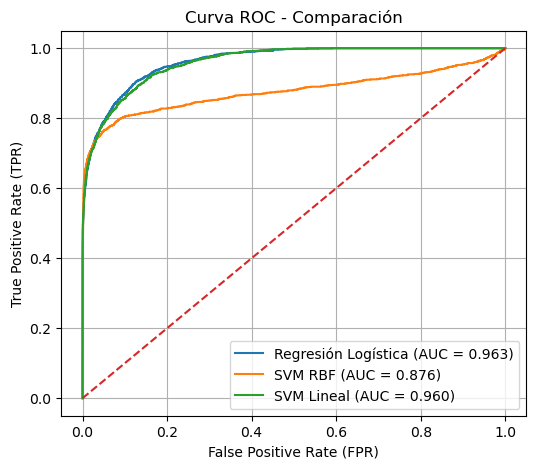

In [22]:
plt.figure(figsize=(6,5))

# ===== REGRESIÓN LOGÍSTICA =====
y_prob = modelo.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.plot(fpr, tpr, label=f"Regresión Logística (AUC = {auc:.3f})")

# ===== SVM RBF =====
y_prob_rbf = svm_rbf.predict_proba(X_test)[:, 1]
fpr_rbf, tpr_rbf, _ = roc_curve(y_test, y_prob_rbf)
auc_rbf = roc_auc_score(y_test, y_prob_rbf)
plt.plot(fpr_rbf, tpr_rbf, label=f"SVM RBF (AUC = {auc_rbf:.3f})")

# ===== SVM LINEAL =====
y_prob_lin = svm_lineal.predict_proba(X_test)[:, 1]
fpr_lin, tpr_lin, _ = roc_curve(y_test, y_prob_lin)
auc_lin = roc_auc_score(y_test, y_prob_lin)
plt.plot(fpr_lin, tpr_lin, label=f"SVM Lineal (AUC = {auc_lin:.3f})")

# Línea diagonal (modelo aleatorio)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Curva ROC - Comparación")
plt.legend()
plt.grid()
plt.show()


In [26]:

valores_C = [0.1, 1, 5, 10, 50, 100]
valores_gamma = [0.001, 0.01, 0.1, 1]
valores_degree = [2, 3, 4, 5]
valores_coef0 = [0, 0.5, 1, 2]

# Funcion que recibe como parametro el tipo de kernel para entrenar el modelo con distintos hiperparametros almacenados en listas
def mejor_eleccion(kernel):
    mejor_acc = 0
    mejor_config = None

    for C in valores_C:

        # LINEAR
        if kernel == 'linear':
            print(f"\nProbando LINEAR | C={C}")

            svm = SVC(kernel='linear', C=C, random_state=42)

            svm.fit(X_train, y_train)
            pred = svm.predict(X_test)
            acc = accuracy_score(y_test, pred)

            print(f"Accuracy: {acc:.4f}")

            if acc > mejor_acc:
                mejor_acc = acc
                mejor_config = ('linear', C)

        # RBF
        elif kernel == 'rbf':
            for gamma in valores_gamma:
                print(f"\nProbando RBF | C={C} | gamma={gamma}")

                svm = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)

                svm.fit(X_train, y_train)
                pred = svm.predict(X_test)
                acc = accuracy_score(y_test, pred)

                print(f"Accuracy: {acc:.4f}")

                if acc > mejor_acc:
                    mejor_acc = acc
                    mejor_config = ('rbf', C, gamma)

        # POLY 
        elif kernel == 'poly':
            for degree in valores_degree:
                for coef0 in valores_coef0:
                    print(f"\nProbando POLY | C={C} | degree={degree} | coef0={coef0}")

                    svm = SVC(kernel='poly', C=C, degree=degree, coef0=coef0, random_state=42)

                    svm.fit(X_train, y_train)
                    pred = svm.predict(X_test)
                    acc = accuracy_score(y_test, pred)

                    print(f"Accuracy: {acc:.4f}")

                    if acc > mejor_acc:
                        mejor_acc = acc
                        mejor_config = ('poly', C, degree, coef0)

    print(f"\nMejor Accuracy: {mejor_acc:.4f}")
    print(f"Mejor configuración: {mejor_config}")


In [ ]:
mejor_eleccion("linear")


Probando LINEAR | C=0.1
Accuracy: 0.9608

Probando LINEAR | C=1
Accuracy: 0.9607

Probando LINEAR | C=5
Accuracy: 0.9607

Probando LINEAR | C=10
Accuracy: 0.9607

Probando LINEAR | C=50
Accuracy: 0.9608

Probando LINEAR | C=100
Accuracy: 0.9608

Mejor Accuracy: 0.9608
Mejor configuración: ('linear', 0.1)


## 5) Resumen
Comparamos resultados en una tabla.

### Preguntas
1. ¿Qué modelo tiene mejor **recall** para la clase positiva (`diabetes=1`)?
2. En un contexto médico, ¿qué error es más grave: **FP** o **FN**? Explica.
3. ¿Qué modelo escogerías si tu prioridad es **interpretabilidad**? ¿y si tu prioridad es **rendimiento**?
4. ¿Por qué el escalado afecta más a SVM que a la logística?
5. Si el dataset está desbalanceado, ¿qué métrica sería más fiable que accuracy?

In [ ]:
# ============================================================
# Cálculo y visualización de la curva ROC y del AUC
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
# Para variar la curva ROC en regresión logística debes modificar:

# C (regularización)

# penalty (consultar documentación oficial)

# Datos de entrenamiento
# ============================================================

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# 1️. Entrenamos modelo (si no lo estuviera ya)
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# 2️. Obtenemos probabilidades de la clase positiva
y_prob = modelo.predict_proba(X_test)[:, 1]

# 3️. Calculamos puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# 4️. Calculamos AUC
auc = roc_auc_score(y_test, y_prob)

print(f"AUC del modelo: {auc:.4f}")

# 5️. Representación gráfica
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Regresión Logística (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")  # Línea diagonal (modelo aleatorio)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Curva ROC")
plt.legend()
plt.grid()
plt.show()
